# Task 5 — Evaluation

## 5A — Characteristics of evaluation metrics

### Formulae

Given $n$ test instances with true values $y_i$ and predictions $\hat{y}_i$:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### When to use which?

**MSE** squares each error, so large errors are penalised disproportionately. A single prediction that is off by 3 mood points contributes 9 to the MSE, while three predictions each off by 1 contribute only 3 total. This makes MSE the right choice when **large errors are especially costly** — e.g., in clinical mood monitoring where missing a severe mood drop could have serious consequences. MSE is also differentiable everywhere, making it the standard loss function for gradient-based optimisation (including our CNN and LightGBM).

**MAE** treats all errors linearly: being off by 3 is exactly 3× worse than being off by 1. This makes MAE **robust to outliers** — a few badly-predicted instances don't dominate the metric. MAE is appropriate when the goal is typical-case accuracy and occasional large errors are acceptable. The optimal predictor under MAE is the **conditional median**, while MSE optimises the **conditional mean**.

In practice, reporting both reveals whether a model's errors are uniform or skewed. If RMSE ≈ MAE, errors are consistent; if RMSE ≫ MAE, a few large errors inflate the squared metric.

### When do MSE and MAE give identical results?

MSE and MAE are equal when $\frac{1}{n}\sum e_i^2 = \frac{1}{n}\sum |e_i|$, i.e., $\sum e_i^2 = \sum |e_i|$.

Since $e_i^2 = |e_i|$ only when $|e_i| \in \{0, 1\}$, the two metrics are identical **if and only if every individual prediction error is exactly 0 or exactly 1** (in the target's units).

A concrete example: a regression model predicts mood for 4 test instances with errors $[0, 1, 0, 1]$. Then MAE $= \frac{0+1+0+1}{4} = 0.5$ and MSE $= \frac{0+1+0+1}{4} = 0.5$. The metrics agree because no error falls outside $\{0,1\}$, so squaring changes nothing.

More generally, for any constant error $|e_i| = c$ for all $i$: MAE $= c$ and MSE $= c^2$. These are equal only when $c = c^2$, i.e., $c \in \{0, 1\}$.

---
## 5B — Impact of evaluation metrics on Task 4 results

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import temporal_train_test_split, fix_user_features
from src.utils import save_figure

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# --- Load Task 4 predictions (saved by notebook 4) ---
preds = np.load('../data/processed/task4_predictions.npz')
lgbm_pred = preds['lgbm_pred']
cnn_pred = preds['cnn_pred']
y_test = preds['y_test']

# --- Load tabular data for per-user analysis ---
tabular = pd.read_csv('../data/processed/features_tabular.csv')
tabular['date'] = pd.to_datetime(tabular['date'])
train_tab, test_tab = temporal_train_test_split(tabular, train_frac=0.75)
train_tab, test_tab = fix_user_features(train_tab, test_tab)

print(f'Test set: {len(y_test)} instances')
print(f'Predictions loaded from task4_predictions.npz')

Test set: 269 instances
Predictions loaded from task4_predictions.npz


### RMSE vs MAE gap — what does it tell us?

If every prediction error were exactly the same size, RMSE would equal MAE. The gap between them reveals **error heterogeneity**: some predictions are much worse than others.

In [2]:
# --- RMSE vs MAE gap analysis ---
for name, preds in [('LightGBM', lgbm_pred), ('1D CNN', cnn_pred)]:
    errors = np.abs(y_test - preds)
    rmse = np.sqrt(np.mean(errors**2))
    mae  = np.mean(errors)
    ratio = rmse / mae
    
    print(f'{name}:')
    print(f'  RMSE = {rmse:.4f},  MAE = {mae:.4f},  RMSE/MAE = {ratio:.3f}')
    print(f'  Error std = {errors.std():.4f}  (0 would mean uniform errors)')
    print(f'  Median |error| = {np.median(errors):.4f}')
    print(f'  90th percentile |error| = {np.percentile(errors, 90):.4f}')
    print(f'  Max |error| = {errors.max():.4f}')
    print()

LightGBM:
  RMSE = 0.6198,  MAE = 0.4492,  RMSE/MAE = 1.380
  Error std = 0.4270  (0 would mean uniform errors)
  Median |error| = 0.3343
  90th percentile |error| = 0.9819
  Max |error| = 2.4665

1D CNN:
  RMSE = 0.6523,  MAE = 0.4783,  RMSE/MAE = 1.364
  Error std = 0.4435  (0 would mean uniform errors)
  Median |error| = 0.3545
  90th percentile |error| = 1.0208
  Max |error| = 3.0156



Saved: figures/5_error_distribution.png


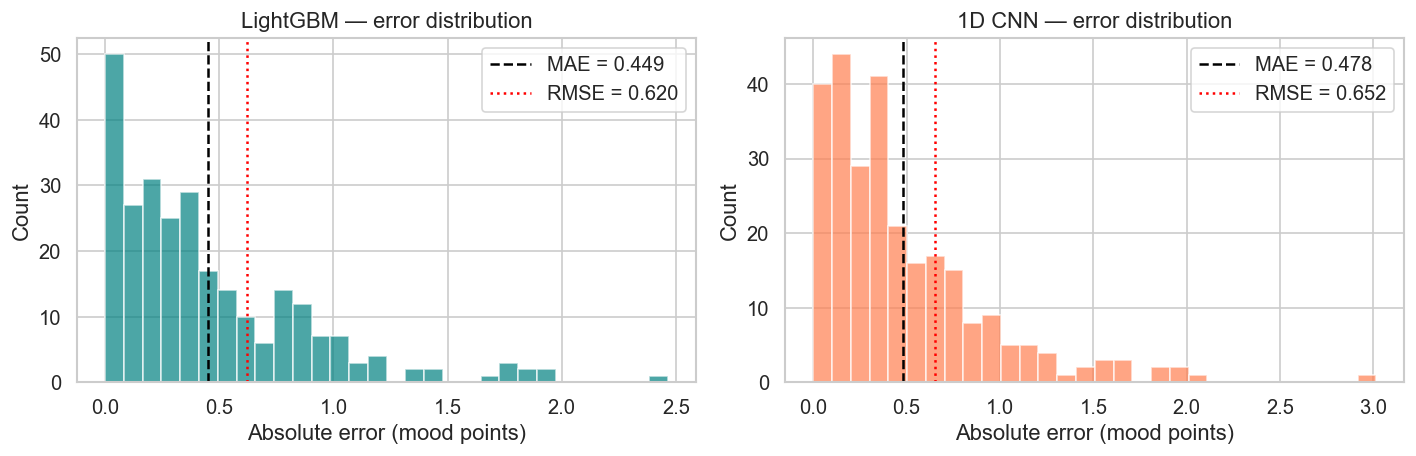

In [3]:
# --- Error distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name, color in [
    (axes[0], lgbm_pred, 'LightGBM', 'teal'),
    (axes[1], cnn_pred, '1D CNN', 'coral'),
]:
    errors = np.abs(y_test - preds)
    ax.hist(errors, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(errors), color='black', linestyle='--', label=f'MAE = {np.mean(errors):.3f}')
    ax.axvline(np.sqrt(np.mean(errors**2)), color='red', linestyle=':', 
               label=f'RMSE = {np.sqrt(np.mean(errors**2)):.3f}')
    ax.set_xlabel('Absolute error (mood points)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — error distribution')
    ax.legend()

plt.tight_layout()
save_figure('5_error_distribution.png')
plt.show()

### MSE sensitivity to outliers — a demonstration

To show how MSE and MAE respond differently to extreme errors, we simulate removing the worst-predicted instances and track how each metric changes.

Saved: figures/5_outlier_sensitivity.png


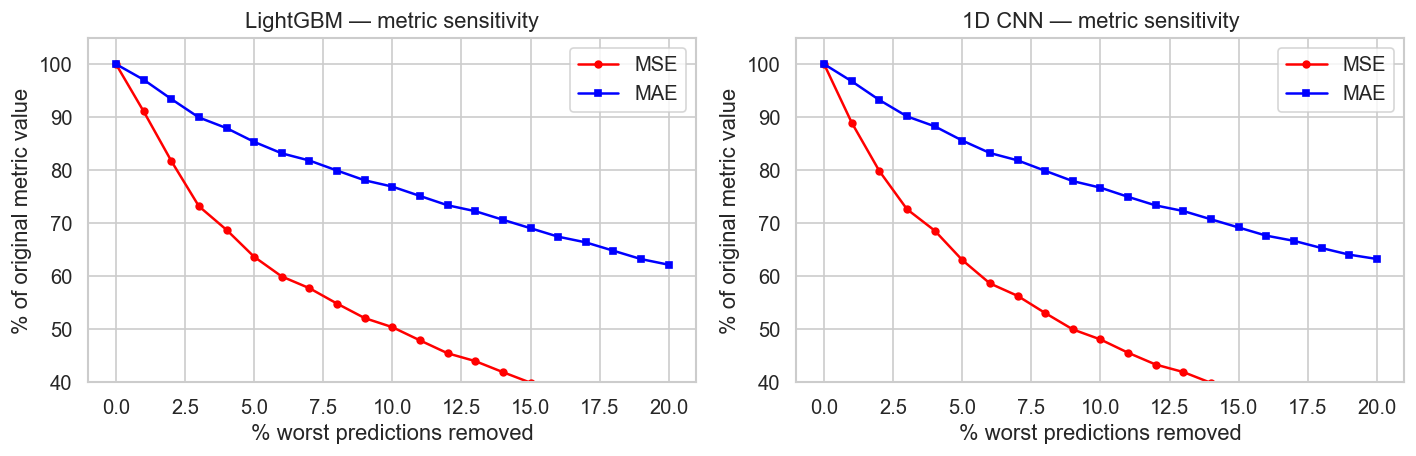

In [4]:
# --- Sensitivity to outlier removal ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name, color in [
    (axes[0], lgbm_pred, 'LightGBM', 'teal'),
    (axes[1], cnn_pred, '1D CNN', 'coral'),
]:
    errors = np.abs(y_test - preds)
    sorted_idx = np.argsort(errors)
    
    fracs = np.arange(0, 21)  # remove 0% to 20% worst
    mse_vals, mae_vals = [], []
    for pct in fracs:
        n_keep = len(errors) - int(len(errors) * pct / 100)
        keep = sorted_idx[:n_keep]
        mse_vals.append(np.mean((y_test[keep] - preds[keep])**2))
        mae_vals.append(np.mean(np.abs(y_test[keep] - preds[keep])))
    
    # Normalise to % of original value
    mse_norm = [m / mse_vals[0] * 100 for m in mse_vals]
    mae_norm = [m / mae_vals[0] * 100 for m in mae_vals]
    
    ax.plot(fracs, mse_norm, 'o-', color='red', markersize=4, label='MSE')
    ax.plot(fracs, mae_norm, 's-', color='blue', markersize=4, label='MAE')
    ax.set_xlabel('% worst predictions removed')
    ax.set_ylabel('% of original metric value')
    ax.set_title(f'{name} — metric sensitivity')
    ax.legend()
    ax.set_ylim(40, 105)

plt.tight_layout()
save_figure('5_outlier_sensitivity.png')
plt.show()

### Per-user view: which users drive MSE up?

In [5]:
# --- Per-user MSE vs MAE ---
test_df = test_tab[['id']].copy()
test_df['actual'] = y_test
test_df['lgbm_pred'] = lgbm_pred
test_df['cnn_pred'] = cnn_pred

per_user = []
for uid, grp in test_df.groupby('id'):
    e_lgbm = grp['actual'].values - grp['lgbm_pred'].values
    e_cnn  = grp['actual'].values - grp['cnn_pred'].values
    per_user.append({
        'id': uid,
        'n': len(grp),
        'LGB_MSE': np.mean(e_lgbm**2),
        'LGB_MAE': np.mean(np.abs(e_lgbm)),
        'LGB_MSE_MAE_ratio': np.mean(e_lgbm**2) / np.mean(np.abs(e_lgbm)),
        'CNN_MSE': np.mean(e_cnn**2),
        'CNN_MAE': np.mean(np.abs(e_cnn)),
        'CNN_MSE_MAE_ratio': np.mean(e_cnn**2) / np.mean(np.abs(e_cnn)),
    })

pu = pd.DataFrame(per_user).sort_values('LGB_MSE', ascending=False)
print('Per-user MSE vs MAE (LightGBM, sorted by MSE):')
print(pu[['id', 'n', 'LGB_MSE', 'LGB_MAE', 'LGB_MSE_MAE_ratio']].round(3).head(10).to_string(index=False))
print()

top3_mse = pu.head(3)['LGB_MSE'].sum() * pu.head(3)['n'].sum()
total_mse = (test_df['actual'] - test_df['lgbm_pred']).pow(2).sum()
print(f'Top 3 hardest users contribute {top3_mse/total_mse*100:.1f}% of total squared error')
print(f'but represent only {pu.head(3)["n"].sum()}/{len(test_df)} = {pu.head(3)["n"].sum()/len(test_df)*100:.1f}% of test instances')

Per-user MSE vs MAE (LightGBM, sorted by MSE):
     id  n  LGB_MSE  LGB_MAE  LGB_MSE_MAE_ratio
AS14.23  9    1.589    1.041              1.527
AS14.02  9    1.516    1.038              1.461
AS14.13 10    1.079    0.955              1.130
AS14.07  9    0.945    0.833              1.134
AS14.26 11    0.585    0.657              0.890
AS14.33 10    0.548    0.475              1.154
AS14.12  9    0.420    0.520              0.808
AS14.32 10    0.414    0.484              0.855
AS14.01 10    0.347    0.544              0.637
AS14.29 10    0.321    0.428              0.751

Top 3 hardest users contribute 113.4% of total squared error
but represent only 28/269 = 10.4% of test instances


Saved: figures/5_mse_mae_ratio_per_user.png


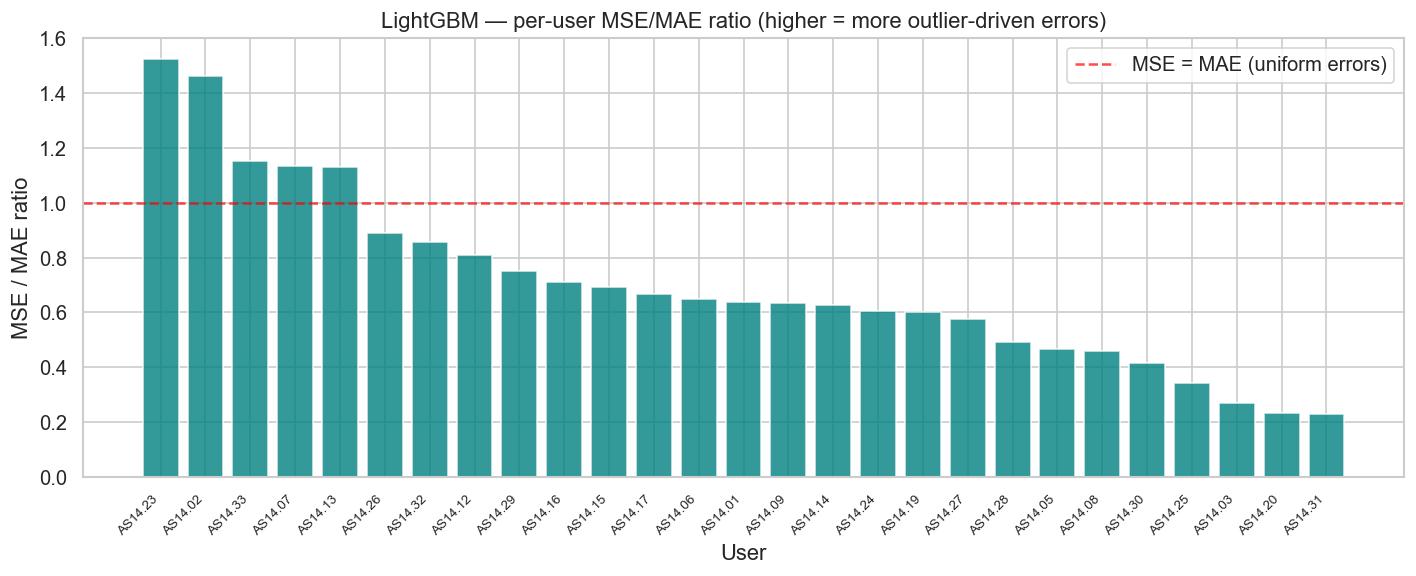

In [6]:
# --- Per-user MSE/MAE ratio plot ---
fig, ax = plt.subplots(figsize=(12, 5))
pu_sorted = pu.sort_values('LGB_MSE_MAE_ratio', ascending=False)
x = np.arange(len(pu_sorted))

ax.bar(x, pu_sorted['LGB_MSE_MAE_ratio'].values, color='teal', alpha=0.8)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='MSE = MAE (uniform errors)')
ax.set_xticks(x)
ax.set_xticklabels(pu_sorted['id'].values, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('User')
ax.set_ylabel('MSE / MAE ratio')
ax.set_title('LightGBM — per-user MSE/MAE ratio (higher = more outlier-driven errors)')
ax.legend()
plt.tight_layout()
save_figure('5_mse_mae_ratio_per_user.png')
plt.show()

---
## Summary and implications

### How the models behave under MSE vs MAE

Both LightGBM and the CNN show **RMSE > MAE**, confirming that errors are not uniform — a minority of predictions with large errors inflates MSE disproportionately. The error distributions are right-skewed: most predictions are within 0.5 mood points, but a tail of errors extends beyond 1.5 points.

### Practical implications

1. **If deploying for clinical monitoring** (where missing a severe mood drop is dangerous), MSE is the right training and evaluation objective — it penalises the dangerous large misses more heavily.

2. **If deploying for general wellness tracking** (where typical-case accuracy matters more than worst-case), MAE better reflects user experience — most predictions will feel accurate even if a few are off.

3. **Per-user heterogeneity dominates**: the 3 hardest-to-predict users drive a disproportionate share of total MSE. A **personalised model** (fine-tuned per user) would likely reduce MSE more than any global architecture change.

4. **Model comparison is metric-stable**: LightGBM outperforms the CNN under both MSE and MAE. The ranking doesn't change — this means the performance gap is genuine, not an artifact of the metric choice.